In [1]:
# usual imports in a classic ML pipeline for Regression
# pip install numpy
# pip install pandas
# pip install seaborn
# pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import helpful features like pipelines etc, also SVM!
from sklearn.model_selection import train_test_split
from sklearn import metrics, svm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# this module makes our life EASIER
# combine this with Pipelines => both X and y -scaling can be automated!
from sklearn.compose import TransformedTargetRegressor

<h3>Data Set Link</h3>
<a href="https://www.kaggle.com/datasets/mohannapd/linear-regression-sales-prediction-of-carseats">
    Linear Regression Sales Prediction of Car Seats Dataset
</a>


<h3>STEP 1 - Load the data </h3>

In [2]:
# load the data
df = pd.read_csv("CarSeats.csv")

# let's quickly see the first 5 rows of data
df.head()


,No,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,5,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [3]:
# do we have missing values? apparently not
# dataset can't have any missing values when passing the data
# to the machine learning algorithm
df.isna().sum()

No             0
Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [137]:
# do we have duplicates?
int(df.duplicated().sum())

0

In [4]:
# drop No field since it is not required
df.drop(columns=['No'], inplace=True)


In [5]:
# Check value counts for ShelveLoc before modifying ordinal categories
df['ShelveLoc'].value_counts()


ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

In [6]:
# Map ShelveLoc - Ordinal categories
category_mapper = {
'Good': 2,
'Medium': 1,
'Bad': 0
}
df['ShelveLoc'] = df['ShelveLoc'].replace(category_mapper)

df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,Yes,Yes
1,11.22,111,48,16,260,83,2,65,10,Yes,Yes
2,10.06,113,35,10,269,80,1,59,12,Yes,Yes
3,7.40,117,100,4,466,97,1,55,14,Yes,Yes
4,4.15,141,64,3,340,128,0,38,13,Yes,No


In [7]:
from sklearn.preprocessing import LabelEncoder

# list all variables that can be binary-converted
variables = ['Urban', 'US']

# load the encoder
encoder = LabelEncoder()

# convert the listed variables
df[variables] = df[variables].apply(encoder.fit_transform)

df.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,2,65,10,1,1
2,10.06,113,35,10,269,80,1,59,12,1,1
3,7.40,117,100,4,466,97,1,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


<h3>All data is now prepared and in numeric format (this data didn't have any categories) </h3>


<h3>X/y and train/test -split</h3>


In [8]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Sales", axis=1)

# our target variable is y
y = df['Sales']

In [9]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Create and train the ML model
NOTICE HERE! TransformedTargetRegressor automatically uses MinMaxScaler for y, and Pipeline automatically uses StandardScaler for X-variables => CONVENIENT!

In [10]:
# create the model and train it with the data
# use pipeline to scale the X-values automatically with StandardScaler

# you can also switch the SVR as you see fit
# model = make_pipeline(StandardScaler(), svm.SVR())
pipeline = make_pipeline(StandardScaler(), svm.LinearSVR())

# thanks to TransformedTargetRegressor, we can also automate
# the y-scaling!!!
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=MinMaxScaler()
)

# train model normally
model.fit(X_train, y_train)

c:\Users\Gayani\OneDrive - lucit\IntroToML\IntroductionToMLMethods\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...LinearSVR())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",MinMaxScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.0
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",1.0


 Error and performance metrics

In [11]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now

# THESE PREDICTIONS ARE IN SCALED FORMAT
predictions = model.predict(X_test)

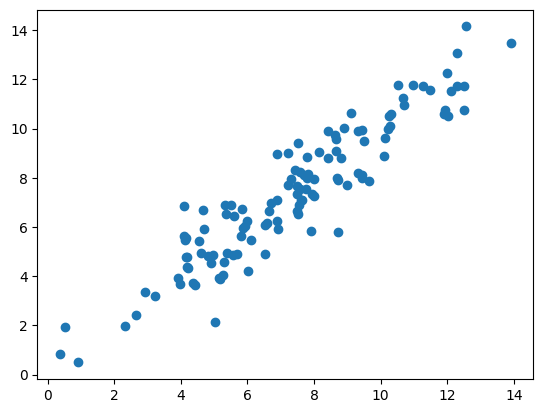

In [12]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences
plt.scatter(y_test, predictions)
plt.show()

<h3> Findings from Scatter Plot </h3>
<li> As actual sales increase, predicted sales also increase </li>
<li> Most predictions are very close to actual sales, and there are no extreme outliers. </li>

In [13]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} $")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")

# THIS IS COMPLETELY OPTIONAL, but it's nice to see a relative as well
# (between 0.0 - 1.0)
# SCALED VERSIONS OF THE METRICS, only use MAE and RMSE
y_test_scaled = model.transformer_.transform(y_test.values.reshape(-1, 1)).ravel()
predictions_scaled = model.transformer_.transform(predictions.reshape(-1, 1)).ravel()

# calculate scaled MAE and RMSE
mae_scaled = metrics.mean_absolute_error(y_test_scaled, predictions_scaled)
rmse_scaled = np.sqrt(metrics.mean_squared_error(y_test_scaled, predictions_scaled))

print(f"\nMAE scaled: {round(mae_scaled, 2)}")
print(f"\nRMSE scaled: {round(rmse_scaled, 2)}")

MAE:
0.8 $

MSE:
1.04 $^2

RMSE:
1.02 $

R-squared:
0.86

MAE scaled: 0.05

RMSE scaled: 0.06


C:\Users\Gayani\AppData\Local\Temp\ipykernel_16376\2920752686.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


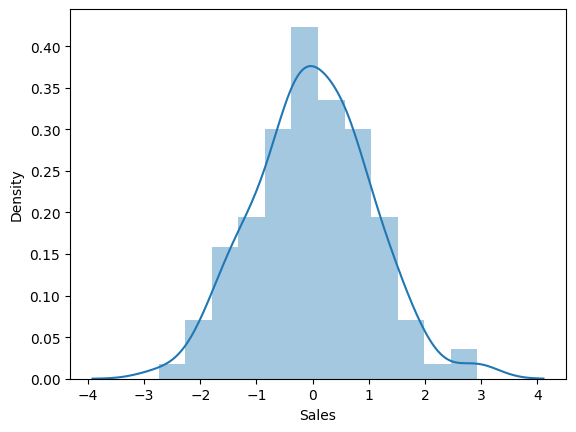

In [14]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far
sns.distplot((y_test - predictions))
plt.show()
plt.close()

Testing/using the model in practice (inference)

In [15]:
X.columns

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='str')

<h3>Test the Trained Regression Model</h3>

In [16]:
tester_row = {
    'CompPrice': 120,
    'Income': 70,
    'Advertising': 10,
    'Population': 300,
    'Price': 100,
    'ShelveLoc': 2,   # encoded (Bad=0, Medium=1, Good=2)
    'Age': 50,
    'Education': 15,
    'Urban': 1,       # Yes=1, No=0
    'US': 1           # Yes=1, No=0
}

tester_row = pd.DataFrame([tester_row])


In [17]:
result = model.predict(tester_row)[0]

print()
print("Predicted sales:")
print(f"{round(float(result), 2)}")
print("----------------------------")



Predicted sales:
11.79
----------------------------


<h3 style="color: blue;">Comparison</h3>


SVR has a predicted sales value of 11.79 and Linera Regression has a predicted sales value of 11.63. According to this:
<ul>
<li>Both models are behaving consistently</li>
<li>SVR is slightly predicting a higher sales value</li>
<li>The variation can be due to Linear-type models → assume straight-line relationships and SVR → can capture non-linear relationships
<br/>
<br/>



“MAE scaled: 0.05” and “RMSE scaled: 0.06” : These are error metrics calculated after scaling the target variable
<ul>
<li>MAE scaled = 0.05: On average, predictions are off by 0.05 (in scaled units)</li>
<li>Since this value is very low Model predictions are close to actual values</li>
RMSE (Root Mean Squared Error): In general No large outliers and model isseem to be stable